# gEval semantic analogies

A purely **geometric** GEval task — no classifier, no CV. Each line is a
quadruplet `(a, b, c, d)` of DBpedia entities; we predict `d` by **3CosAdd**:
the nearest neighbour (cosine) to `b - a + c` over the **full 1.28M vocab**,
excluding `a/b/c`. Scored by **top-k accuracy**. Mirrors GEval's
`semanticAnalogies_model.py`.

| dataset | relation tested | example (a:c :: b:d) |
|---|---|---|
| **capital_country** | capital → country | Athens:Greece :: Baghdad:Iraq |
| **all_capital_country** | capital → country (larger) | " |
| **currency** | country → currency | Algeria:Dinar :: Angola:Kwanza |
| **city_state** | US city → US state | Chicago:Illinois :: Houston:Texas |

This probes whether **relational structure** survived in the space — a different
question from clustering/classification (which probe class separability). It is
also a *hard* top-1 test: the answer must beat all 1.28M vocab entries.

Gold: `evaluation_framework/SemanticAnalogies/data/*.txt` → `v1/geval/analogies/`.
Logic: [`scripts/_geval.py`](../scripts/_geval.py).

In [1]:
import sys
from pathlib import Path
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scripts import _geval
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
OUT = REPO / "notebooks" / "geval_analogies"; OUT.mkdir(exist_ok=True)
DATASETS = list(_geval.ANALOGY_DATASETS)
# Bound family: only the norm-capped (cap16) variants are used; the no-cap
# p{1,2,3}_bound are excluded from every gEval experiment.
ORDER = ["vanilla", "p1_classic", "p2_classic", "p3_classic",
         "p2_bound_cap16", "p3_bound_cap16"]
print("datasets:", DATASETS)

datasets: ['capital_country', 'all_capital_country', 'currency', 'city_state']


## 1. Coverage — fully-answerable quadruplets (all 4 URIs in vocab)

A quad is only scorable if `a`, `b`, `c` **and** `d` are all in the shared vocab.
Same vocab across variants, so checked once.

In [2]:
vocab = _geval.load_vocab("vanilla")
pd.DataFrame([_geval.analogy_coverage(ds, vocab) for ds in DATASETS]).set_index("dataset")

,total,answerable,coverage
dataset,,,
capital_country,506,506,1.000
all_capital_country,4524,4139,0.915
currency,866,598,0.691
city_state,2467,1935,0.784


## 2. Top-k accuracy per dataset (3CosAdd, full-vocab nearest neighbour)

`n` = scorable quadruplets. This cell does a full-vocab NN search per quad per
variant, so it is the slowest notebook (a few minutes).

In [3]:
results = {ds: _geval.evaluate_analogies(ds, variants=ORDER) for ds in DATASETS}
for ds in DATASETS:
    print(f"\n===== {ds} =====")
    print(results[ds].reindex(ORDER)[["top1","top2","n"]].to_string())


===== capital_country =====
                top1  top2       n
vanilla        0.676 0.769 506.000
p1_classic     0.802 0.877 506.000
p2_classic     0.832 0.911 506.000
p3_classic     0.866 0.933 506.000
p2_bound_cap16 0.709 0.771 506.000
p3_bound_cap16 0.650 0.719 506.000

===== all_capital_country =====
                top1  top2        n
vanilla        0.721 0.795 4139.000
p1_classic     0.491 0.544 4139.000
p2_classic     0.487 0.557 4139.000
p3_classic     0.495 0.560 4139.000
p2_bound_cap16 0.256 0.322 4139.000
p3_bound_cap16 0.244 0.317 4139.000

===== currency =====
                top1  top2       n
vanilla        0.579 0.607 598.000
p1_classic     0.321 0.356 598.000
p2_classic     0.365 0.396 598.000
p3_classic     0.299 0.343 598.000
p2_bound_cap16 0.472 0.528 598.000
p3_bound_cap16 0.457 0.498 598.000

===== city_state =====
                top1  top2        n
vanilla        0.152 0.270 1935.000
p1_classic     0.321 0.391 1935.000
p2_classic     0.304 0.382 1935.000
p3_cla

## 3. Summary — top-1 accuracy by variant × dataset (the money table)

In [4]:
top1 = pd.DataFrame({ds: results[ds]["top1"] for ds in DATASETS}).reindex(ORDER)
top1.style.background_gradient(cmap="RdYlGn", vmin=0, vmax=1, axis=None).format("{:.3f}")

,capital_country,all_capital_country,currency,city_state
vanilla,0.676,0.721,0.579,0.152
p1_classic,0.802,0.491,0.321,0.321
p2_classic,0.832,0.487,0.365,0.304
p3_classic,0.866,0.495,0.299,0.307
p2_bound_cap16,0.709,0.256,0.472,0.230
p3_bound_cap16,0.650,0.244,0.457,0.232


## 4. Grouped bar — top-1 accuracy by variant × dataset

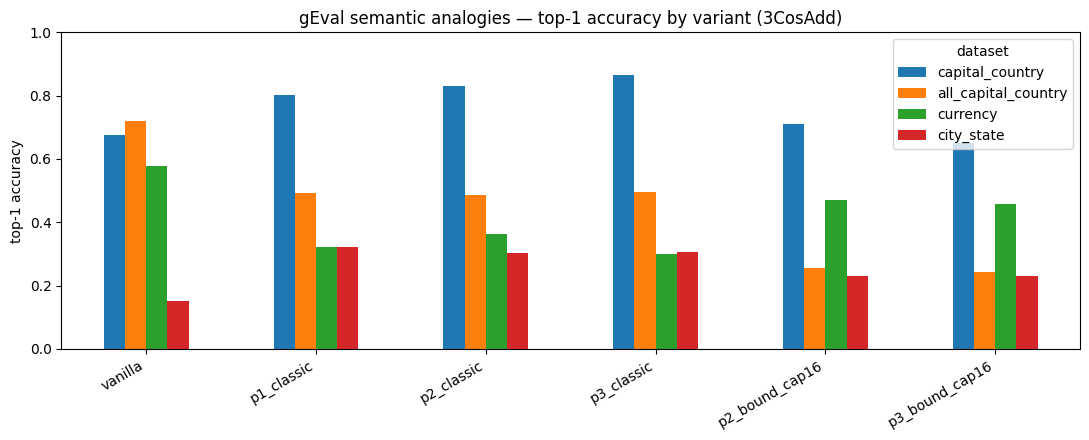

In [5]:
ax = top1.plot.bar(figsize=(11, 4.5))
ax.set_title("gEval semantic analogies — top-1 accuracy by variant (3CosAdd)")
ax.set_ylabel("top-1 accuracy"); ax.set_ylim(0, 1)
ax.legend(title="dataset"); plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.savefig(OUT / "geval_analogy_top1.png", dpi=120); plt.show()

## Takeaways

Analogies give a **third, distinct pattern** — neither the clustering result nor
the classification/regression result. There is **no consistent winner**: `classic`
wins two datasets, `vanilla` the other two, and `cap16` sits in between.

- **`classic` vs `vanilla` flips with answer-set scale.** On the small
  **capital_country** (506) and on **city_state**, class-mean init wins clearly
  (p3_classic 0.866 vs vanilla 0.676; classic ~0.31 vs vanilla 0.152). But on the
  large **all_capital_country** (4139) and **currency**, `vanilla` wins decisively
  (0.721 vs classic ~0.49; 0.579 vs classic ~0.33). Plausible mechanism: class-mean
  init pulls every country toward a shared "country" centroid — great for *coarse*
  separation but it **blurs the within-class identity** 3CosAdd needs to retrieve one
  *specific* country out of hundreds. vanilla keeps co-occurrence-specific positions.
- **The capped bound is a genuine middle performer here** — not the floor it is on
  clustering. `*_bound_cap16` actually **beats `vanilla`** on capital_country (0.709
  vs 0.676) and lands second on currency and city_state. Analogies are far more
  forgiving of bound geometry than k-means clustering, where cap16 stays pinned at
  the vanilla floor (CC/CCB ARI ~0.02).
- **Reading across all four tasks:** clustering rewards class-mean init and floors
  the bound-cap; classification & regression flatten everyone and let bound-cap
  compete; analogies reward class-mean init **only at small answer-set scale** and
  rank bound-cap in the middle. No single variant is "best" — the right embedding is
  task- *and* scale-relative. This is the strongest multi-task evidence that the
  DLCC ranking does not transfer.